### **Polynomial Regression - Normalized**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# loading the data into a numpy array

data = np.loadtxt("data/noisy_2.txt", delimiter=" ")
data.shape

(10000, 2)

In [3]:
# intializing the feature and target variables

x = data[:, 0]
y = data[:, 1]

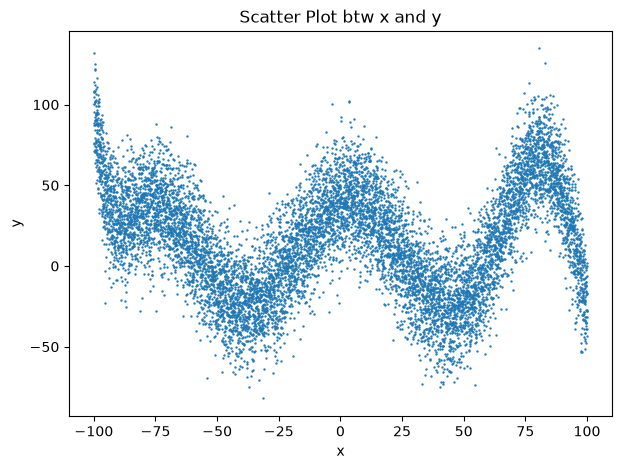

In [4]:
# examining the relationship between the feature and the target variable

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot btw x and y")
plt.savefig("../docs/lab3/submissions/figures/data_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

**Note :** The relationship between input feature and the target variable is *non-linear*

In [5]:
# intializing the seed for reproducibility, as we are gonna shuffle the data.

np.random.seed(42)

indices = np.random.permutation(len(x))

x_shuffled = x[indices]
y_shuffled = y[indices]

In [6]:
# splitting the data into train, validation and test sets.

train_end = int(0.6 * len(x))   # 60% for training
val_end = int(0.8 * len(x))     # 20% for validation and remaining for testing

x_train = x_shuffled[:train_end]
y_train = y_shuffled[:train_end]

x_val = x_shuffled[train_end:val_end]
y_val = y_shuffled[train_end:val_end]

x_test = x_shuffled[val_end:]
y_test = y_shuffled[val_end:]

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(6000,) (6000,)
(2000,) (2000,)
(2000,) (2000,)


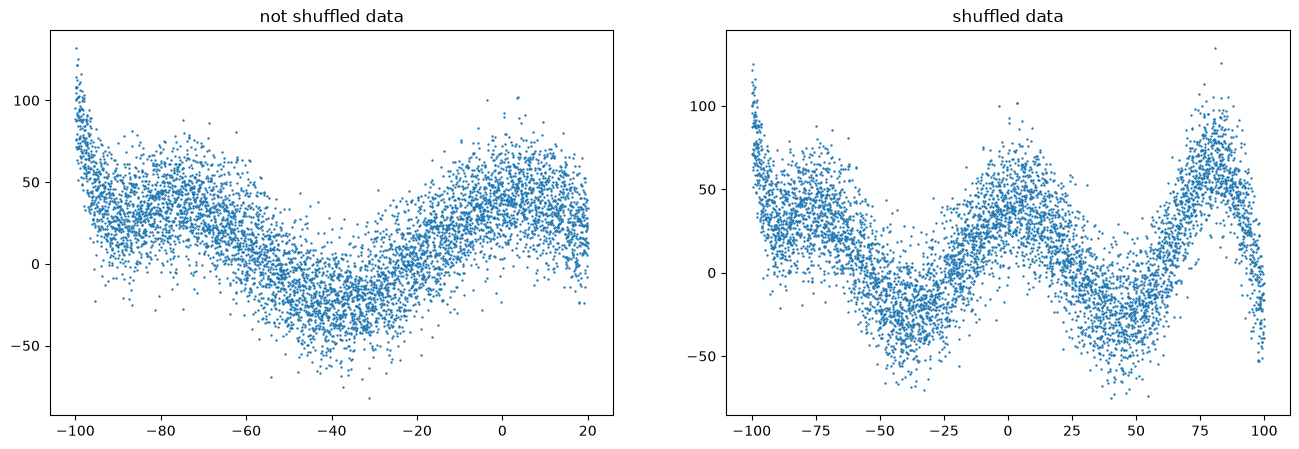

In [7]:
# just curious on how the data looks like before and after shuffling.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.scatter(x[:train_end], y[:train_end], s=0.5)
ax1.set_title("not shuffled data")

ax2.scatter(x_shuffled[:train_end], y_shuffled[:train_end], s=0.5)
ax2.set_title("shuffled data")
plt.savefig("../docs/lab3/submissions/figures/shuffle_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

Shuffling really helped in capturing the overall structure into train-set, rather than cutting off at value x=20

In [8]:
# function for creating the polynomial basis

def polynomial_basis(x, degree):
  X = np.ones((len(x), degree + 1))

  for power in range(1, degree + 1):
    X[:, power] = x ** power

  return X

test_basis = polynomial_basis(x_train, degree=3)  # testing by creating a 3rd degree polynomial basis
test_basis[:3]

array([[ 1.00000000e+00,  2.50525053e+01,  6.27628019e+02,
         1.57236542e+04],
       [ 1.00000000e+00, -6.31063106e+00,  3.98240644e+01,
        -2.51314978e+02],
       [ 1.00000000e+00, -6.53765377e+01,  4.27409168e+03,
        -2.79425315e+05]])

The values are quite large. We might need to scale it down.

In [9]:
# standardizing the feature and target variables

x_mean = np.mean(x_train)
x_std = np.std(x_train)
y_mean = np.mean(y_train)
y_std = np.std(y_train)

x_train_scaled = (x_train - x_mean) / x_std
x_val_scaled = (x_val - x_mean) / x_std
x_test_scaled = (x_test - x_mean) / x_std
y_train_scaled = (y_train - y_mean) / y_std

The mean and std are calculated from the training set to avoid data leakage.

In [10]:
degree_3_basis = polynomial_basis(x_train_scaled, degree=3)
degree_3_basis[:3]

array([[ 1.00000000e+00,  4.55779967e-01,  2.07735378e-01,
         9.46816236e-02],
       [ 1.00000000e+00, -8.73288771e-02,  7.62633277e-03,
        -6.65999077e-04],
       [ 1.00000000e+00, -1.11016077e+00,  1.23245695e+00,
        -1.36822536e+00]])

The values are properly scaled down now - mean 0 and std 1.

**Solving the Normal Equation Using the Pseudoinverse**

In [11]:
# function for solving the normal equation.

def least_squares_solution(degree, x, y):

    X = polynomial_basis(x, degree)

    A = X.T @ X
    b = X.T @ y

    weights = np.linalg.inv(A) @ b
    return weights

In [12]:
# function for making predictions using calcuated weights and spliting out the error

def predict(degree, x, weights):

    X = polynomial_basis(x, degree)
    y_pred = X @ weights

    return y_pred

In [13]:
# function to calculate the mean squared error (MSE)

def mse(y_actual, y_pred):
  return np.mean((y_actual - y_pred) ** 2)

In [14]:
# calculating solution for 3rd degree polynomial and making predictions on the training set.

degree = 3
weights_d3 = least_squares_solution(degree, x_train_scaled, y_train_scaled)
y_train_pred_scaled = predict(degree, x_train_scaled, weights_d3)
y_val_pred_scaled = predict(degree, x_val_scaled, weights_d3)

y_train_pred = y_train_pred_scaled * y_std + y_mean
y_val_pred = y_val_pred_scaled * y_std + y_mean

In [15]:
# calculating the MSE for the train and validation sets.

train_mse = mse(y_train, y_train_pred)
val_mse = mse(y_val, y_val_pred)

print(f"Train MSE: {train_mse:.4f}")
print(f"Validation MSE: {val_mse:.4f}")

Train MSE: 961.7099
Validation MSE: 901.5841


### **Compare different Degrees of Polynomial**

In [16]:
degrees = range(1, 16)

train_errors = []
val_errors = []

for degree in degrees:
    weights = least_squares_solution(degree, x_train_scaled, y_train_scaled)

    y_train_pred = predict(degree, x_train_scaled, weights) * y_std + y_mean
    y_val_pred = predict(degree, x_val_scaled, weights) * y_std + y_mean

    train_error = mse(y_train, y_train_pred)
    val_error = mse(y_val, y_val_pred)

    train_errors.append(train_error)
    val_errors.append(val_error)

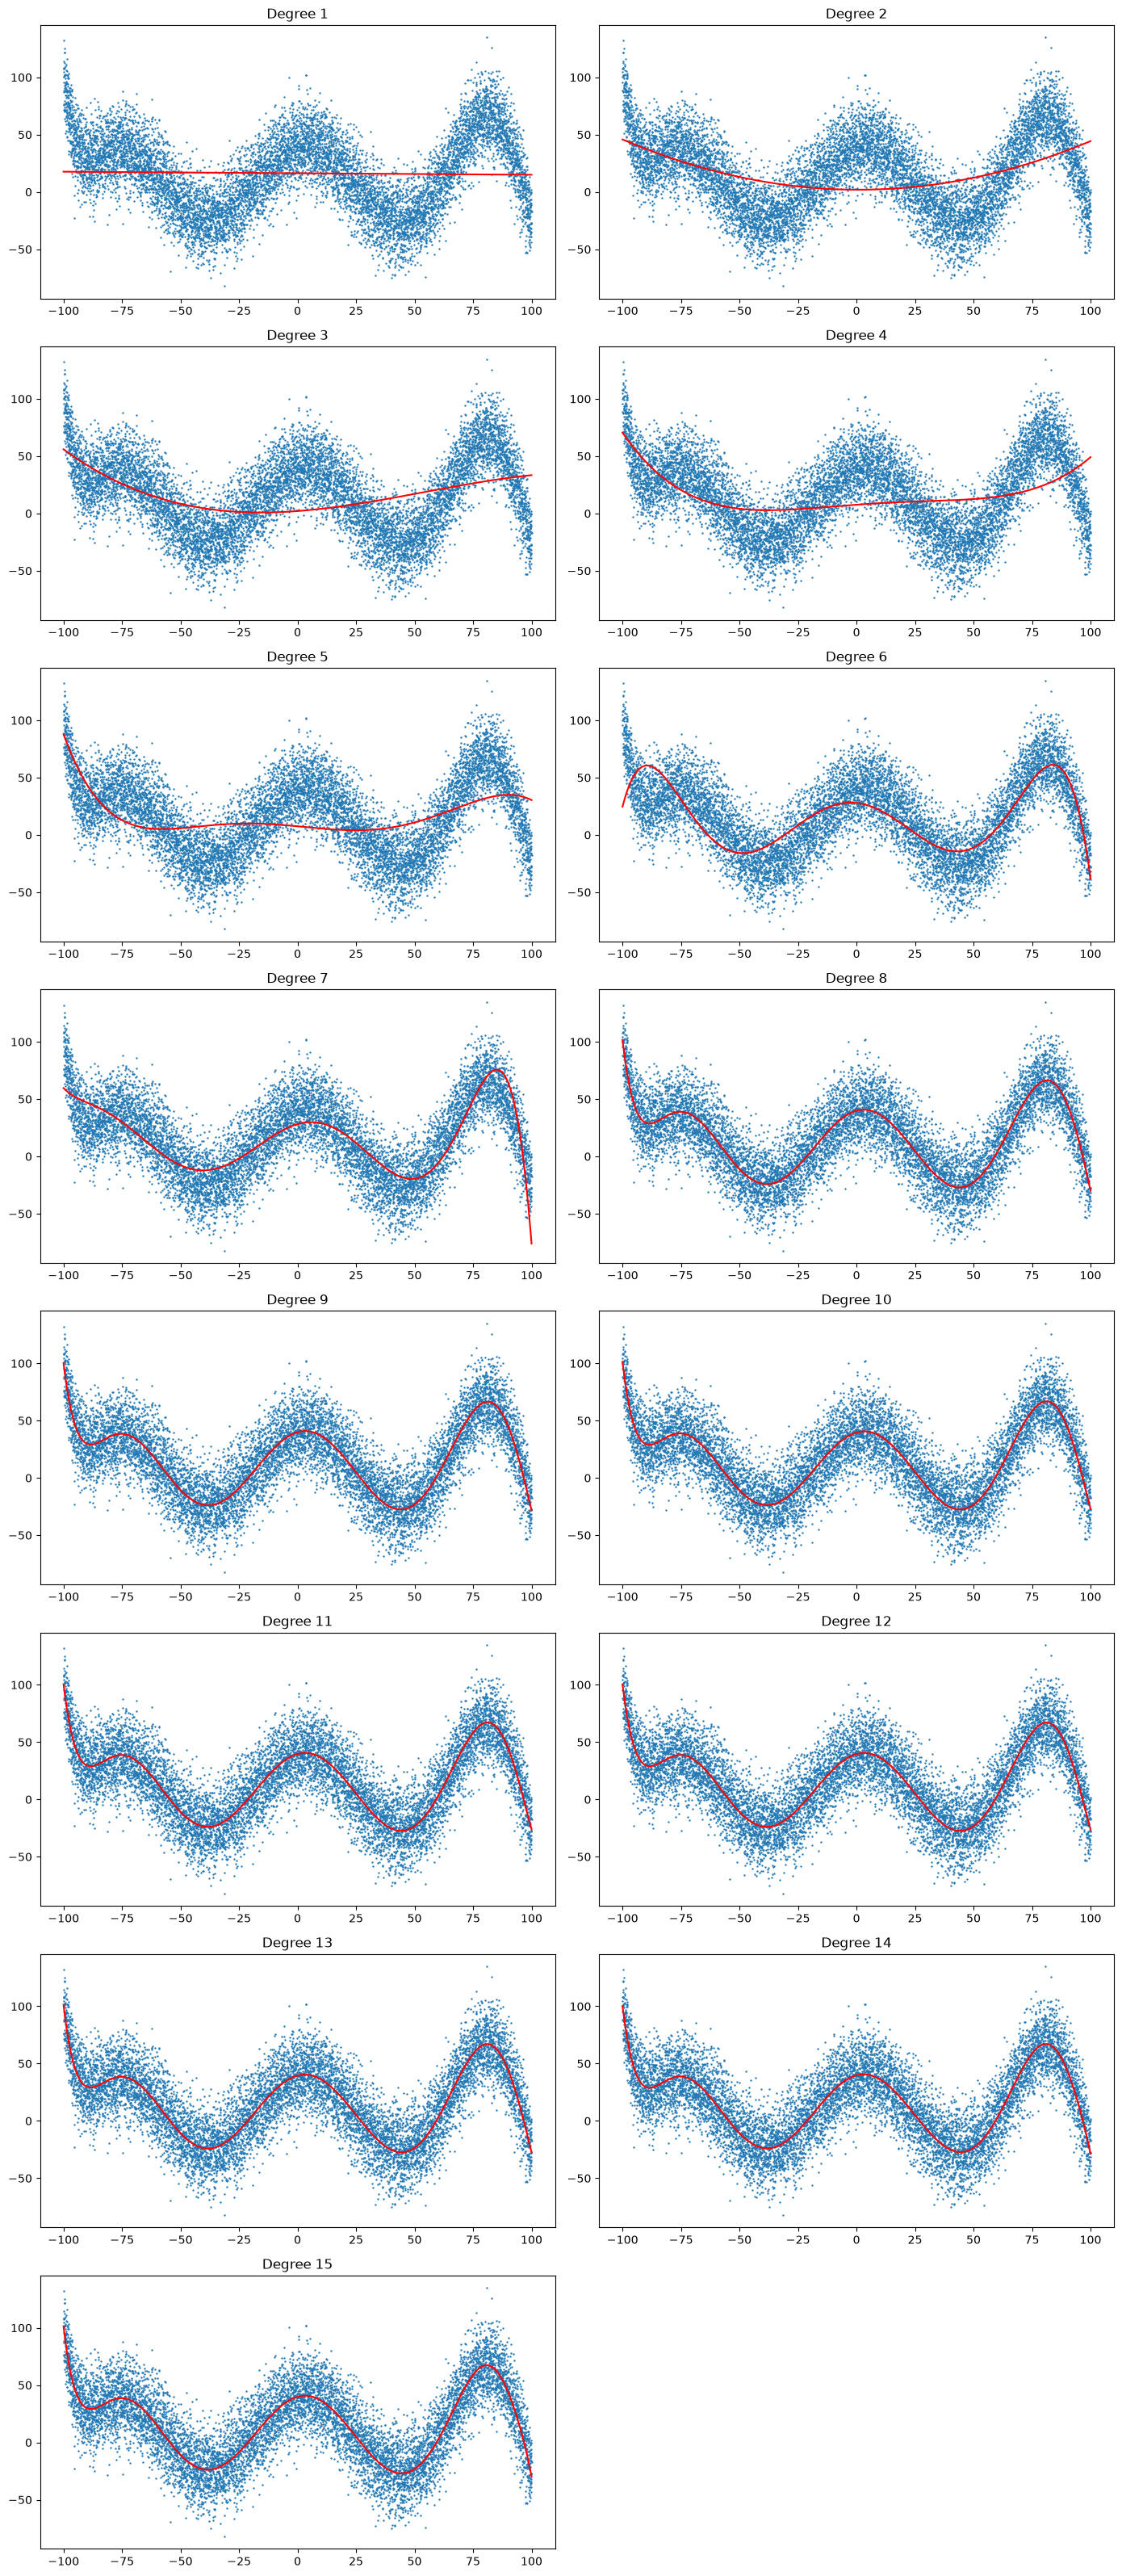

In [17]:
# plotting the fitted curves from degree 1 to degree 15

x_scaled = (x - x_mean) / x_std
fig, axes = plt.subplots(8, 2, figsize=(14, 32))
axes = axes.flatten()

for index, degree in enumerate(degrees):
    weights = least_squares_solution(degree, x_train_scaled, y_train_scaled)
    y_curve = predict(degree, x_scaled, weights) * y_std + y_mean

    axes[index].scatter(x, y, s=0.5)
    axes[index].plot(x, y_curve, color="red")
    axes[index].set_title(f"Degree {degree}")

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../docs/lab3/submissions/figures/polynomial_fits_degrees_1_to_15.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

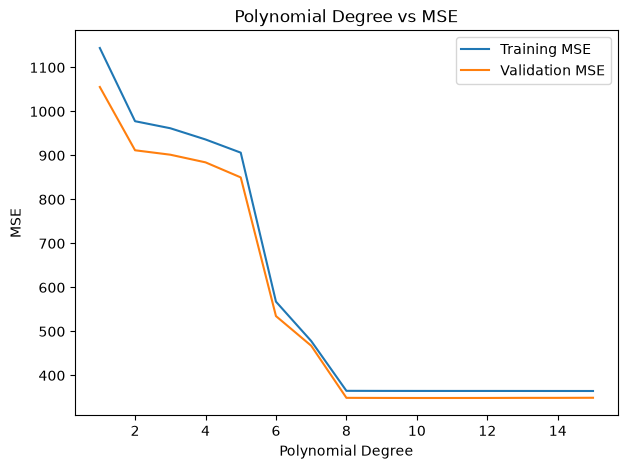

Best Degree : 10


In [18]:
# ploting train vs validation errors across different degrees

plt.figure(figsize=(7, 5))
plt.plot(degrees, train_errors, label="Training MSE")
plt.plot(degrees, val_errors, label="Validation MSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Polynomial Degree vs MSE")
plt.legend()
plt.savefig("../docs/lab3/submissions/figures/degree_mse_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Best Degree : {degrees[np.argmin(val_errors)]}")

Therefore we can conclude that Polynomial with degree 10 has the best fit.

### **Testing the Model (10th degree Polynomial) on Test set**

In [19]:
# fitting the final degree 10 model using train and validation data

x_train_final = np.concatenate((x_train, x_val))
y_train_final = np.concatenate((y_train, y_val))

x_mean_final = np.mean(x_train_final)
x_std_final = np.std(x_train_final)
y_mean_final = np.mean(y_train_final)
y_std_final = np.std(y_train_final)

x_train_final_scaled = (x_train_final - x_mean_final) / x_std_final
x_test_final_scaled = (x_test - x_mean_final) / x_std_final
y_train_final_scaled = (y_train_final - y_mean_final) / y_std_final

best_degree = 10
final_weights = least_squares_solution(best_degree, x_train_final_scaled, y_train_final_scaled)

y_test_pred_scaled = predict(best_degree, x_test_final_scaled, final_weights)
y_test_pred = y_test_pred_scaled * y_std_final + y_mean_final
test_mse = mse(y_test, y_test_pred)

print(f"Final Test MSE: {test_mse:.4f}")

Final Test MSE: 340.0071


In [20]:
# final weights

print(final_weights)

[ 0.69922908  1.10233004 -8.54811865 -3.73244626 11.88910168  3.23235814
 -5.09773153 -0.84636065  0.60460428  0.03393497  0.0303174 ]


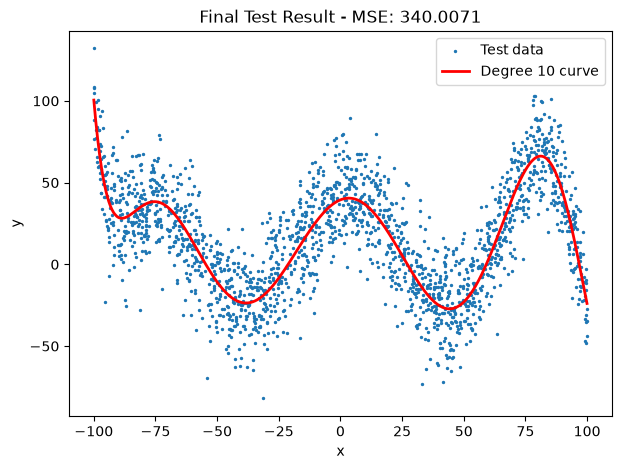

In [21]:
# plotting the final degree 10 curve on the test data

test_order = np.argsort(x_test)

plt.figure(figsize=(7, 5))
plt.scatter(x_test, y_test, s=2, label="Test data")
plt.plot(x_test[test_order], y_test_pred[test_order], color="red", linewidth=2, label="Degree 10 curve")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Final Test Result - MSE: {test_mse:.4f}")
plt.legend()
plt.savefig("../docs/lab3/submissions/figures/test_fit_degree_10.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()